# Plot a given ETC and its associated SPC storm reports, and snowfall

In [1]:
### Importing necessary packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings
#warnings.filterwarnings('ignore')
import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import cmocean
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import seaborn as sns
import xarray as xr

##Add more as needed
## custom packages
#from stormevents_utils import standardize_and_convert_to_utc, build_begin_datetime, load_stormevents_data
#from TE_processing import parse_nodefile, filter_tracks

In [2]:
# ETC tracks:
tracks = pd.read_csv('/home1/lepique/circs_research/data/nodes_with_reports_final.csv',
                     parse_dates=['time_hour'])   # needed for the .dt accessor later
etc_summary = pd.read_csv('/home1/lepique/circs_research/data/etc_summary_final.csv')
# SPC storm reports:
reports = pd.read_csv('/home1/lepique/circs_research/data/reports_tagged_final.csv', low_memory=False)
# snowfall (just for a quick look; plotting uses get_storm_snow below)
ds = xr.open_dataset('/data1/lepique/etc_snowfall/storm_totals_nohrsc_cap12.nc')

In [5]:
ds['storm_total_snowfall_depth']

<xarray.DataArray 'storm_total_snowfall_depth' (track_id: 2225, latitude: 197,
                                                longitude: 389)> Size: 682MB
[170508425 values with dtype=float32]
Coordinates:
  * track_id   (track_id) int32 9kB 1 2 3 4 5 6 ... 6114 6116 6117 6119 6120
  * latitude   (latitude) float64 2kB 61.0 60.75 60.5 60.25 ... 12.5 12.25 12.0
  * longitude  (longitude) float64 3kB 216.0 216.2 216.5 ... 312.5 312.8 313.0
Attributes:
    units:               m
    long_name:           Storm-total snowfall accumulation DEPTH, Hawcroft ra...
    _FillValue_meaning:  NaN = not attributed (see status), 0.0 = attributed,...

In [4]:
ds['storm_total_snowfall_depth'].units

'm'

In [5]:
reports = reports.dropna(subset='track_id').copy()
reports['track_id'] = reports['track_id'].astype(int)

In [6]:
SNOW_FILES = {
    "era5":   ("/data1/lepique/etc_snowfall/storm_totals_era5_cap12.nc",
               "storm_total_sf"),
    "nohrsc": ("/data1/lepique/etc_snowfall/storm_totals_nohrsc_cap12.nc",
               "storm_total_snowfall_depth"),
}
DAY_INDEX = "/data1/lepique/etc_snowfall/{product}_cap12/etc_day_index.csv"
CAP_RADIUS = 12.0        # great-circle degrees (Hawcroft et al. 2012)
M_TO_IN = 39.37


def get_storm_snow(track_id, product="nohrsc", swe_ratio=10.0, min_val=0.5):
    """
    Storm-total snowfall for one ETC, ready to contour.

    Returns (DataArray in INCHES on a -180..180 grid, colorbar label, meta dict),
    or (None, None, meta) if the storm has no attributed snowfall.

    Two conversions happen here, and both are mandatory:
      * longitude 0-360 -> -180..180, to match the track/report coordinates
      * metres -> inches; for ERA5 also water-equivalent -> depth via `swe_ratio`,
        since ERA5 `sf` is SWE while NOHRSC is snow depth.
    """
    path, var = SNOW_FILES[product]
    with xr.open_dataset(path) as ds:
        da = ds[var].sel(track_id=int(track_id)).load()
        meta = {"status": str(ds.status.sel(track_id=int(track_id)).values),
                "n_days": int(ds.n_days.sel(track_id=int(track_id))),
                "first": str(ds.first_spc_day.sel(track_id=int(track_id)).values),
                "last":  str(ds.last_spc_day.sel(track_id=int(track_id)).values)}

    if meta["status"] != "ok" or meta["n_days"] == 0:
        print(f"track {track_id}: status={meta['status']}, n_days={meta['n_days']}"
              " -> no snowfall attributed")
        return None, None, meta

    da = da.assign_coords(longitude=da.longitude - 360.0) * M_TO_IN
    if product == "era5":
        da = da * swe_ratio
        label = f"ERA5 storm-total snowfall (in, {swe_ratio:g}:1 from SWE)"
    else:
        label = "NOHRSC storm-total snowfall (in, depth)"

    # below the lowest contour -> NaN so the zero background isn't painted
    return da.where(da >= min_val), label, meta


def cap_circle(lon0, lat0, radius_deg=CAP_RADIUS, n=181):
    """Points on the great-circle circle of angular radius `radius_deg`."""
    lat0, lon0, r = np.radians(lat0), np.radians(lon0), np.radians(radius_deg)
    th = np.linspace(0, 2 * np.pi, n)
    lat = np.arcsin(np.sin(lat0) * np.cos(r) + np.cos(lat0) * np.sin(r) * np.cos(th))
    lon = lon0 + np.arctan2(np.sin(th) * np.sin(r) * np.cos(lat0),
                            np.cos(r) - np.sin(lat0) * np.sin(lat))
    return np.degrees(lon), np.degrees(lat)

## Picking a case

Merge the cyclone summary with the storm-total summaries to find storms that are
big in *both* hazards.

In [7]:
def plot_track_case(reports_tagged, track_h, track_id, snow=None, snow_label=None,
                    snow_meta=None, product="nohrsc", show_cap=False,
                    zoom=False, savepath=None):
    """
    Plot one cyclone track, its associated storm reports, and its storm-total
    snowfall footprint.

    snow / snow_label / snow_meta come from get_storm_snow(). `snow` carries its
    own latitude/longitude coordinates, so no separate lon/lat arrays are needed.
    """
    case_reports = reports_tagged[reports_tagged['track_id'] == track_id].copy()
    case_track = track_h[track_h['track_id'] == track_id].sort_values('time_hour')
    if case_track.empty:
        print(f'No track found for track_id={track_id}')
        return

    proj_lcc = ccrs.LambertConformal(central_longitude=-99.0, central_latitude=35.0,
                                     standard_parallels=[35.0])
    fig = plt.figure(figsize=(14, 10), dpi=150)
    ax = plt.axes(projection=proj_lcc)
    transform = ccrs.PlateCarree()

    ## geography
    ax.coastlines(resolution='50m', color='black', linewidths=0.8)
    ax.add_feature(cfeature.BORDERS, linewidths=0.8, edgecolor='black')
    state_borders = cfeature.NaturalEarthFeature(
        category='cultural', name='admin_1_states_provinces_lakes',
        scale='50m', facecolor='none')
    ax.add_feature(state_borders, edgecolor='black', linewidth=0.5, zorder=4)

    if zoom:
        lons = np.concatenate([case_track['lon'].values,
                               case_reports['report_lon'].dropna().values])
        lats = np.concatenate([case_track['lat'].values,
                               case_reports['report_lat'].dropna().values])
        ax.set_extent([lons.min() - 4, lons.max() + 4,
                       lats.min() - 2, lats.max() + 3], crs=transform)
    else:
        ax.set_extent([-122.0, -72.5, 21.5, 50.0], crs=transform)

    ## --- 1. snowfall (Tomer Burg's contouring logic) ---
    if snow is not None:
        clevs = [0.5, 1, 2, 3, 4, 6, 8, 12, 16, 20, 24, 30, 36, 48, 60]
        colors = ['#bdd7e7', '#6baed6', '#3182bd', '#08519c', '#082694',
                  '#ffff96', '#ffc400', '#ff8700', '#db1400', '#9e0000',
                  '#690000', '#ccccff', '#9f8cd8', '#7c52a5', '#561c72']
        # 15 levels -> 14 bins; the last colour is the over-range colour
        cmap = col.ListedColormap(colors[:len(clevs) - 1])
        cmap.set_over(colors[-1])
        norm = col.BoundaryNorm(clevs, cmap.N)

        cs = ax.contourf(snow.longitude.values, snow.latitude.values, snow.values,
                         levels=clevs, cmap=cmap, norm=norm, extend='max',
                         transform=transform, zorder=1)
        cbar = plt.colorbar(cs, ax=ax, shrink=0.6, pad=0.02, ticks=clevs)
        cbar.set_label(snow_label or 'Storm-total snowfall (in)', fontsize=12)

    ## --- 2. Hawcroft cap footprint (optional) ---
    if show_cap:
        di = pd.read_csv(DAY_INDEX.format(product=product), parse_dates=['spc_day'])
        di = di[di['track_id'] == track_id]
        for _, r in di.iterrows():
            clon, clat = cap_circle(r['lon'] - 360.0, r['lat'])
            ax.plot(clon, clat, color='0.35', linewidth=0.9, linestyle='--',
                    alpha=0.8, transform=ccrs.Geodetic(), zorder=2)
        ax.scatter(di['lon'] - 360.0, di['lat'], s=45, marker='x', color='0.25',
                   linewidth=1.4, transform=transform, zorder=3,
                   label=f'00Z cap centre ({CAP_RADIUS:g}°)')

    ## --- 3. track line + nodes (coloured by MSL) ---
    case_track_6h = case_track[case_track['time_hour'].dt.hour % 6 == 0]
    ax.plot(case_track['lon'], case_track['lat'], color='black', linewidth=2,
            alpha=0.8, transform=transform, zorder=5)
    sc = ax.scatter(case_track_6h['lon'], case_track_6h['lat'],
                    c=case_track_6h['msl'], cmap=cmocean.cm.dense_r,
                    s=70, edgecolor='black', linewidth=0.5,
                    transform=transform, zorder=6, label='ETC node (6-hourly)')
    cbar2 = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
    cbar2.set_label('ETC MSL (hPa)', fontsize=12)

    ## --- 4. storm reports ---
    if not case_reports.empty:
        et = case_reports['EVENT_TYPE'].str.upper().fillna('OTHER')
        is_tor = et.str.contains('TORNADO')
        is_hail = et.str.contains('HAIL')
        is_wind = et.str.contains('THUNDERSTORM WIND')

        ax.scatter(case_reports.loc[is_wind, 'report_lon'],
                   case_reports.loc[is_wind, 'report_lat'],
                   s=15, c='blue', alpha=0.7, transform=transform,
                   label='T-Storm Wind', zorder=7,
                   edgecolor='black', linewidth=0.2)
        ax.scatter(case_reports.loc[is_hail, 'report_lon'],
                   case_reports.loc[is_hail, 'report_lat'],
                   s=15, c='lime', alpha=0.7, transform=transform,
                   label='Hail', zorder=8,
                   edgecolor='black', linewidth=0.2)
        ax.scatter(case_reports.loc[is_tor, 'report_lon'],
                   case_reports.loc[is_tor, 'report_lat'],
                   s=40, c='red', alpha=0.7, transform=transform,
                   label='Tornado', zorder=9, marker='v',
                   edgecolor='black', linewidth=0.5)
    ax.legend(loc='lower left', fontsize=11, framealpha=0.9)

    ## --- title ---
    t0 = case_track['time_hour'].min().strftime('%Y-%m-%d %H:%M')
    t1 = case_track['time_hour'].max().strftime('%Y-%m-%d %H:%M')
    title = (f"Track {int(track_id)} | {t0} → {t1} UTC | "
             f"min MSL {case_track['msl'].min():.1f} hPa | "
             f"{len(case_reports)} reports")
    if snow_meta and snow_meta.get('n_days'):
        # the snow window is usually SHORTER than the track: only the SPC days
        # whose 00Z cap reached the CONUS grid are attributed
        title += (f"\nsnowfall: {product.upper()} {snow_meta['first']} → "
                  f"{snow_meta['last']} ({snow_meta['n_days']} SPC days, "
                  f"{CAP_RADIUS:g}° cap)")
    plt.title(title, fontsize=14, fontweight='bold', loc='left')
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

In [8]:
## candidates: lots of reports AND lots of snow
s_era5 = pd.read_csv('/data1/lepique/etc_snowfall/storm_totals_era5_cap12_summary.csv')
s_noh  = pd.read_csv('/data1/lepique/etc_snowfall/storm_totals_nohrsc_cap12_summary.csv')

cand = (etc_summary.assign(track_id=etc_summary.track_id.astype(int))
        .merge(s_era5[['track_id', 'field_max', 'n_days']], on='track_id')
        .merge(s_noh[['track_id', 'field_max']], on='track_id',
               suffixes=('_era5', '_nohrsc')))
cand['era5_in']   = cand.field_max_era5 * 39.37 * 10    # SWE -> depth at 10:1
cand['nohrsc_in'] = cand.field_max_nohrsc * 39.37

(cand[(cand.n_reports > 40) & (cand.nohrsc_in > 10)]
 .sort_values('n_reports', ascending=False)
 [['track_id', 'track_start', 'track_end', 'n_reports', 'n_tornado',
   'min_msl', 'n_days', 'era5_in', 'nohrsc_in']].head(10))

,track_id,track_start,track_end,n_reports,n_tornado,min_msl,n_days,era5_in,nohrsc_in
2211,6102,2025-03-06 19:00:00+00:00,2025-03-27 15:00:00+00:00,1080,147,968.5919,11,33.150020,17.228699
1609,4387,2017-02-26 02:00:00+00:00,2017-03-01 18:00:00+00:00,1022,78,989.8938,3,19.694438,45.396988
1243,3372,2012-03-01 01:00:00+00:00,2012-03-09 17:00:00+00:00,937,108,945.2594,4,14.395572,32.100322
2222,6117,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,927,66,992.6212,6,12.097536,13.806710
1612,4391,2017-03-05 12:00:00+00:00,2017-03-09 18:00:00+00:00,801,76,963.3794,4,23.556882,21.232624
1934,5421,2021-12-14 10:00:00+00:00,2021-12-25 14:00:00+00:00,784,167,968.2650,4,16.986492,23.838208
1298,3558,2013-01-26 18:00:00+00:00,2013-02-04 00:00:00+00:00,782,75,940.1319,6,24.504687,41.863361
1532,4178,2016-02-22 18:00:00+00:00,2016-02-29 07:00:00+00:00,591,75,965.2694,5,16.941813,17.341623
2104,5849,2024-01-04 17:00:00+00:00,2024-01-14 01:00:00+00:00,582,45,973.7175,9,23.965220,20.450880
2202,6090,2025-02-14 11:00:00+00:00,2025-02-18 10:00:00+00:00,575,28,958.3869,4,21.156227,36.856544


## Plot

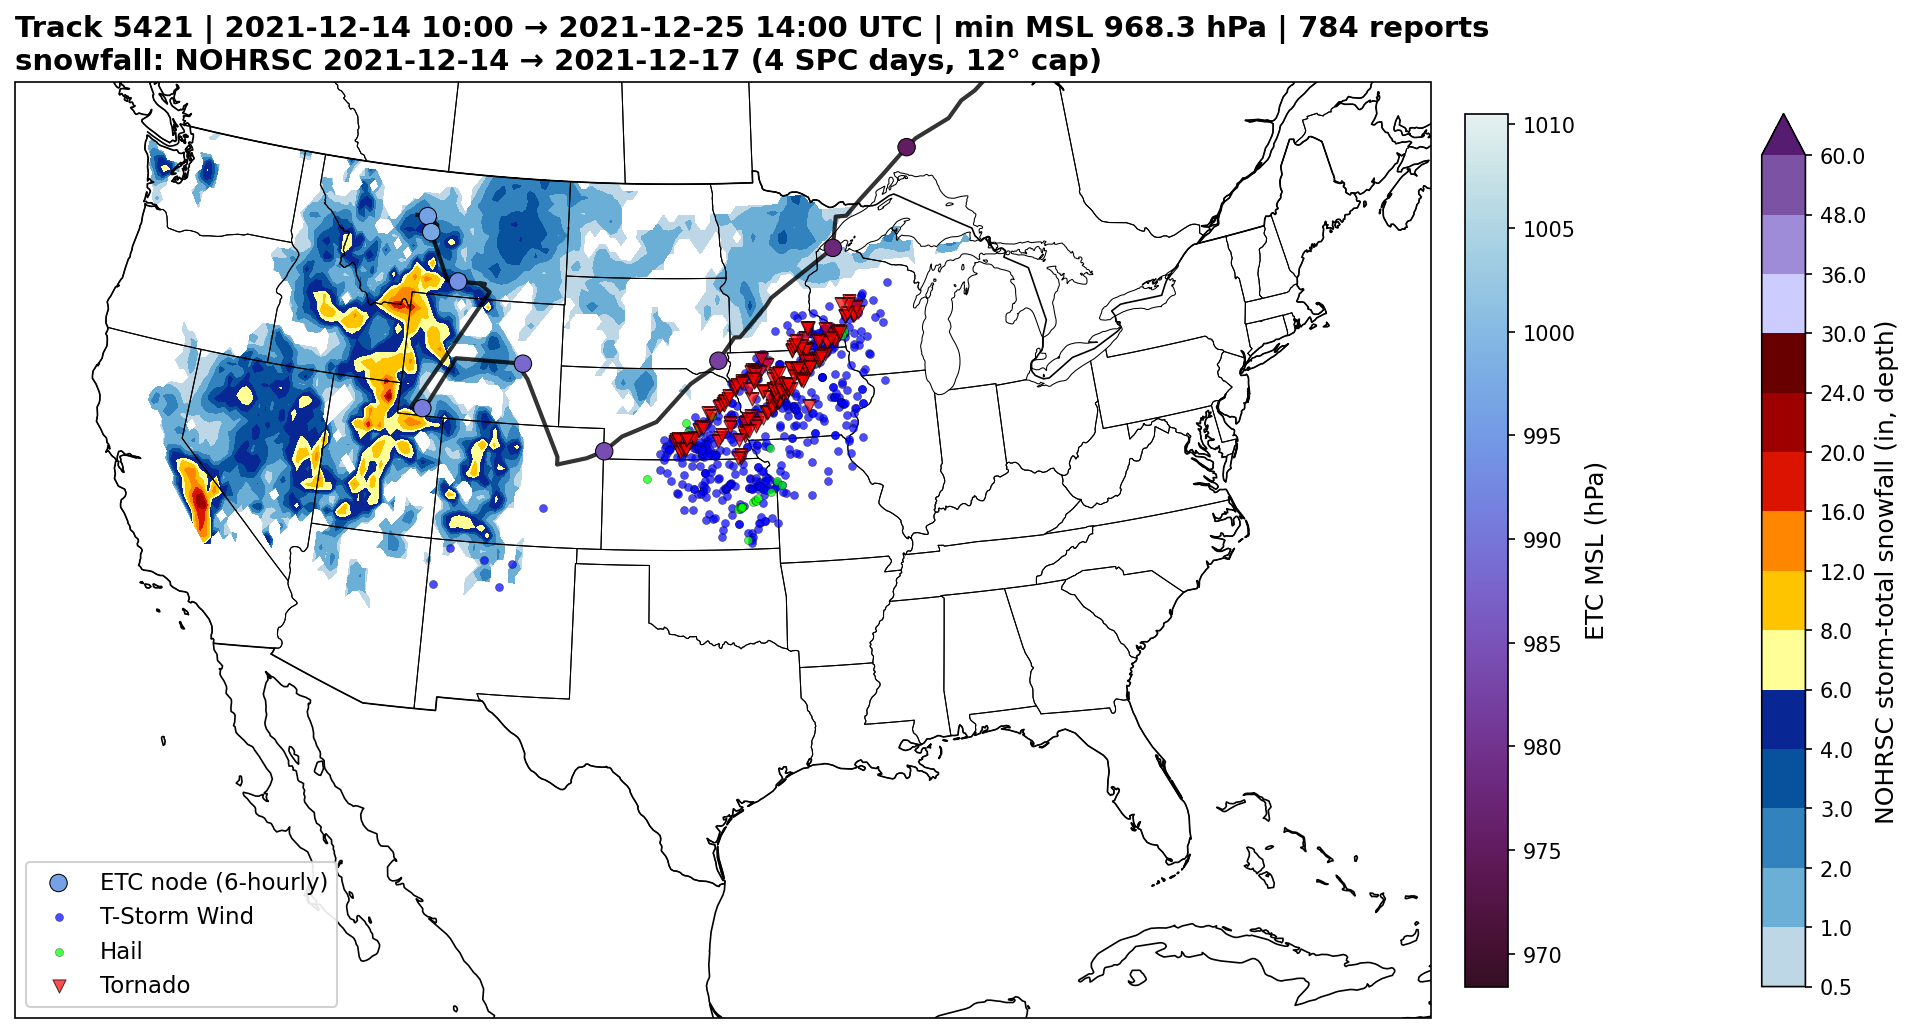

In [9]:
tid = 5421   # 14-25 Dec 2021: serial derecho + western snow

snow, snow_label, snow_meta = get_storm_snow(tid, product='nohrsc')
plot_track_case(reports, tracks, tid, snow=snow, snow_label=snow_label,
                snow_meta=snow_meta, product='nohrsc')

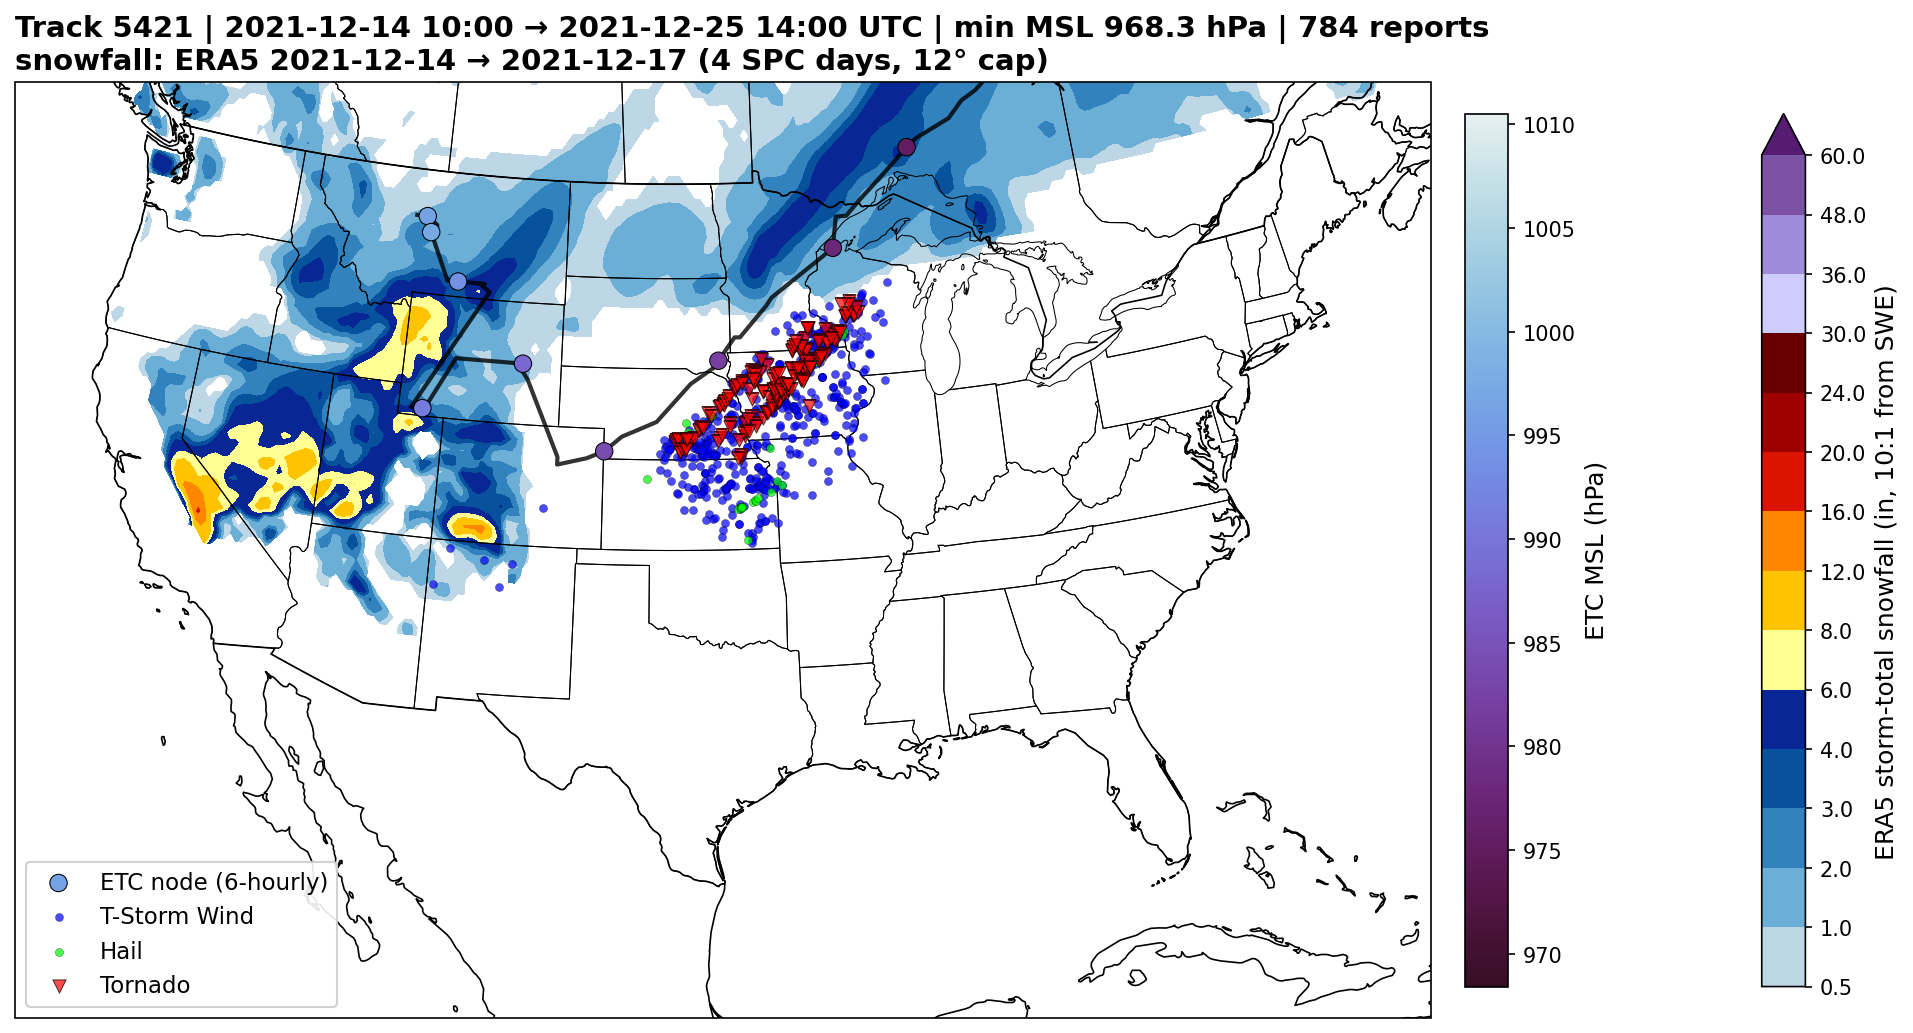

In [ ]:
## same storm, ERA5 (water equivalent -> depth at 10:1)
snow_e, label_e, meta_e = get_storm_snow(tid, product='era5', swe_ratio=10.0)
plot_track_case(reports, tracks, tid, snow=snow_e, snow_label=label_e,
                snow_meta=meta_e, product='era5')

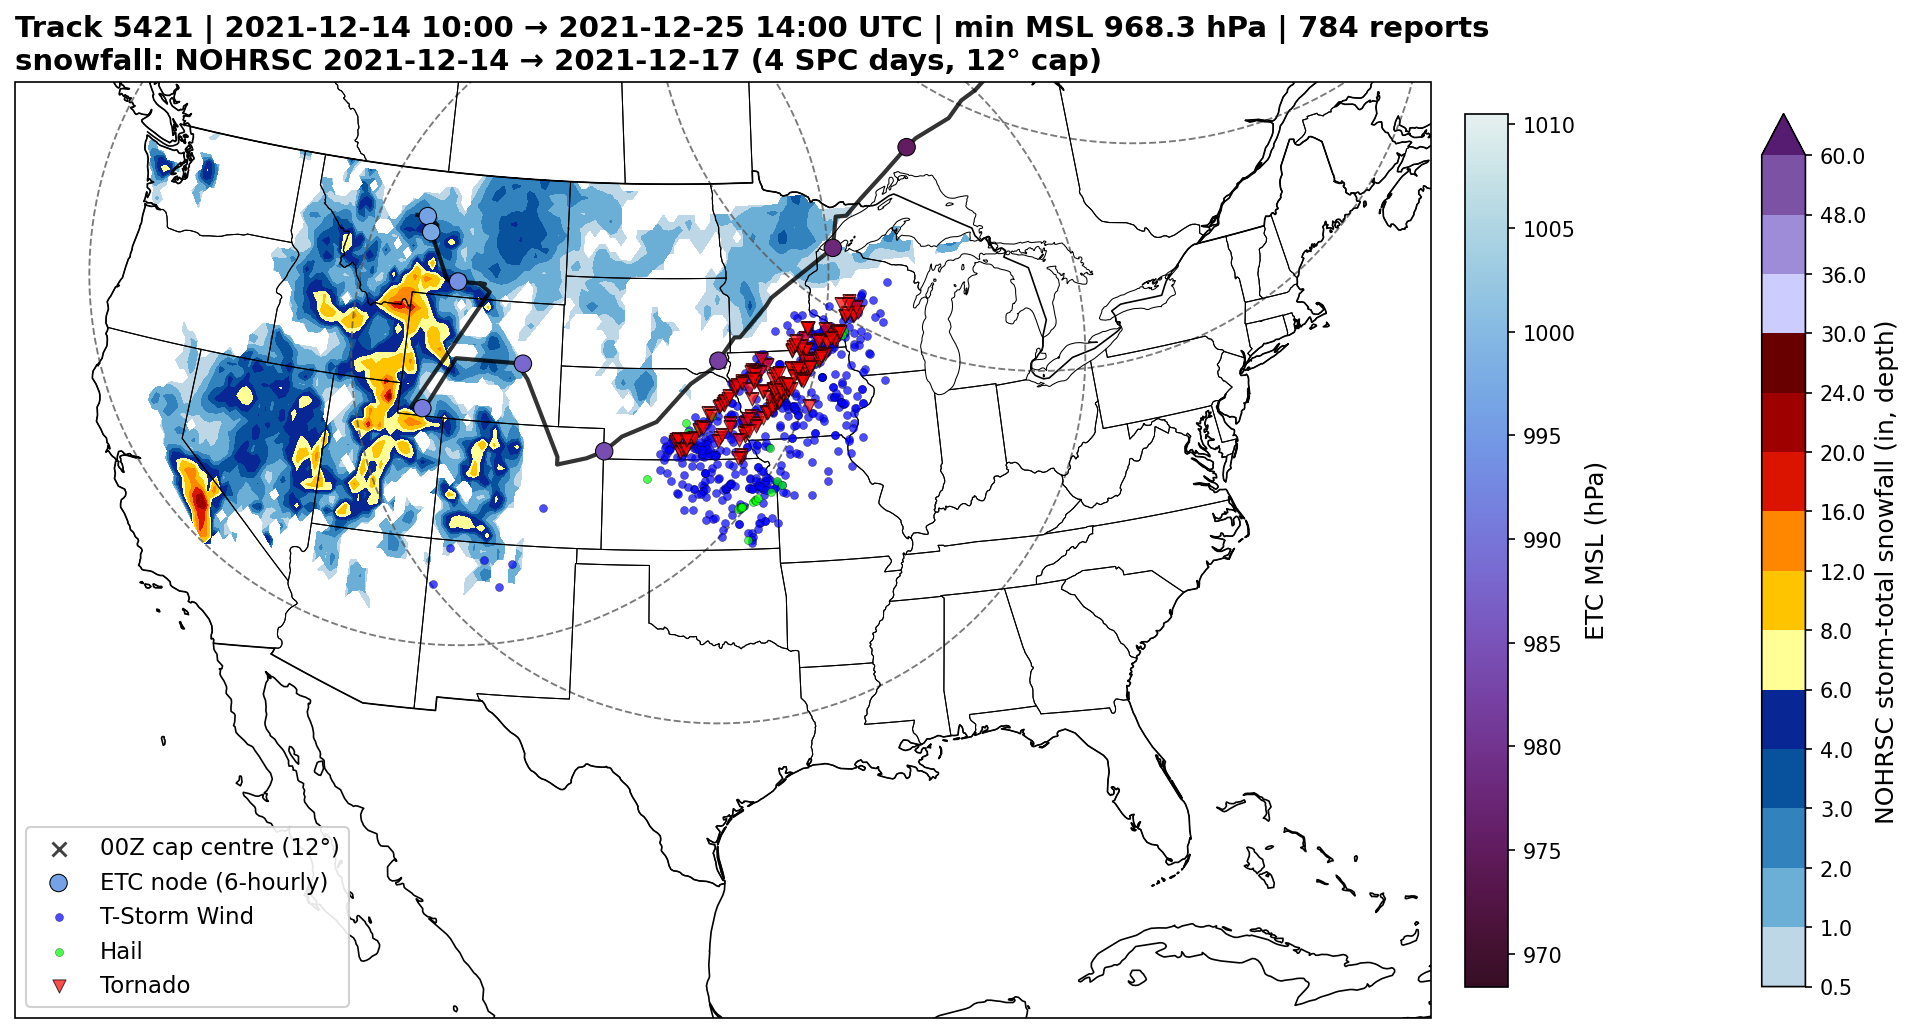

In [11]:
## show the Hawcroft caps that produced the footprint
plot_track_case(reports, tracks, tid, snow=snow, snow_label=snow_label,
                snow_meta=snow_meta, product='nohrsc', show_cap=True)